In [ ]:
from datascience import *
from prob140 import *
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline
from statsmodels.distributions.empirical_distribution import ECDF

# Nonparametric Bootstrap

We'll take a closer look at the bootstrap confidence intervals covered in Data 8 and 100. We will describe an alternative way of constructing bootstrap confidence intervals that is often better.

In Data 8, the [bootstrap method](https://inferentialthinking.com/chapters/13/2/Bootstrap.html#the-bootstrap-resampling-from-the-sample) assumes that the sample $X_1, X_2, \ldots, X_n$ is i.i.d. from some distribution but it doesn't assume any particular parametric form for that distribution. This is the *nonparametric bootstrap* setting.

Assume that the sample is i.i.d. from a distribution with cdf $F$. We are interested a parameter associated with $F$, for example, the median of $F$. We construct one estimate of this parameter based on our sample. To give ourselves some wiggle room, we need a measure of the variability of our statistic across samples. For this, we need more samples.

Typically, we can't sample again from $F$. So we need some way to figure out the variability in our statistic without drawing more samples from $F$. One way is to use math and probability theory, as we did for the means of large i.i.d. samples. But for complicated statistics, finding the variability analytically is sometimes intractable.

So we resort to computing. As you know, the bootstrap method treats the original sample as a substitute for the population samples $n$ times at random with replacement from the original sample. This is called *resampling*. It is easy to resample, so we can repeat the resampling process as many times as we wish.

Formally, we sample from the empirical distribution of the sample. Define the *empirical cdf* of the sample by

$$
F_n(x) ~ = ~ \frac{1}{n} \sum_{i=1}^n I(X_i \le x), ~~~~~ -\infty < x < \infty
$$

For each $x$, $F_n(x)$ is the proportion of sampled elements whose values are are at most $x$. 

By the WLLN, for each $x$ we have $F_n(x) \xrightarrow{P} F(x)$. In fact the convergence is stronger but we won't go into that. The figure below shows that the empirical cdf of the sample is close to the cdf from which the data were drawn, in the case where we have an i.i.d. sample of size 100 from the standard normal distribution.

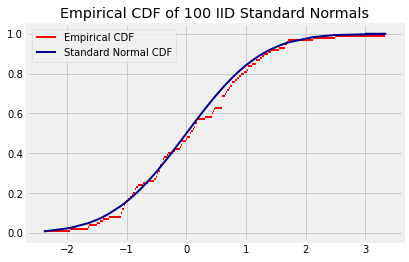

In [3]:
n=100
sorted_z = np.sort(stats.norm.rvs(size=n))
ecdf = ECDF(sorted_z)
f = ecdf(sorted_z)
for i in range(n-1):
    plt.plot([sorted_z[i], sorted_z[i+1]], [f[i], f[i]], color='red', lw=2)
plt.plot([sorted_z[n-1], 3], [1,1], lw=2, color='red', label='Empirical CDF')
plt.plot(np.append(sorted_z, 3), np.append(stats.norm.cdf(sorted_z), 1), lw=2, color='darkblue', label='Standard Normal CDF')
plt.legend()
plt.title('Empirical CDF of '+str(n)+' IID Standard Normals');

Let our statistic be $T(X_1, X_2, \ldots, X_n)$. The bootstrap procedure can be described as follows, with $B$ denoting the number of replications of the resampling process.

Do the following $B$ times:

- Draw an i.i.d. sample $X_1^*, X_2^*, \ldots, X_n^*$ from $F_n$.
- Find $T(X_1^*, X_2^*, \ldots, X_n^*)$.

This results in $B$ i.i.d. copies of $T$, each drawn from $F_n$. These $B$ values create a bootstrap empirical distribution of $T$. If $n$ and $B$ are both large, this empirical distribution is likely to be close to the distribution of $T$.

### Percentile Method ###
To construct a $100(1-\alpha)\%$ confidence interval for the parameter, take the $100(\alpha/2)$ and $100(1 - \alpha/2)$ percentiles of the bootstrap empirical distribution of $T$ as the two endpoints.

This was the method used in Data 8 and 100. It has the advantage of simplicity, and it works well if the distribution of $T$ is roughly symmetric and centered at the parameter. Like all equal tail intervals, it is easily transformed to estimate a monotone function of the parameter.

If $T$ is biased, however, the percentile method might not be a good choice. For example, if $T$ tends to underestimate the parameter, then the bootstrap estimate $T(X_1^*, X_2^*, \ldots, X_n^*)$ will tend to underestimate $T$, making the problem worse.

### Basic or Empirical Bootstrap Method ###
Let $\theta$ be the parameter being estimated. An unsettling aspect of the percentile method is that the original estimate $\hat{\theta} = T(X_1, X_2, \ldots, X_n)$ isn't used in the calculation. The *basic* or *empirical bootstrap* method uses $\hat{\theta}$ and attempts to address the problem of bias. This is a common method of calculating bootstrap confidence intervals and has stronger theoretical justification than the percentile method. 

In essence, the method approximates the distribution of the error $\delta = \hat{\theta} - \theta$, instead of the distribution of the estimator $T$. Let $\delta_{\alpha/2}$ and $\delta_{1-\alpha/2}$ be the $100(\alpha/2)$ and $100(1-\alpha/2)$ percentiles of the the distribution of $\delta$. Then

$$
\begin{align*}
1-\alpha ~ &= ~ P(\delta_{\alpha/2} < \delta < \delta_{1-\alpha/2}) \\
&= ~ P(\delta_{\alpha/2} < \hat{\theta} - \theta < \delta_{1-\alpha/2}) \\
&= ~ P(\hat{\theta} - \delta_{1-\alpha/2} < \theta < \hat{\theta} - \delta_{\alpha/2})
\end{align*}
$$

So $(\hat{\theta} - \delta_{1-\alpha/2}, \hat{\theta} - \delta_{\alpha/2})$ is a $100(1-\alpha)\%$ confidence interval for $\theta$.

But we don't know $\theta$, so we don't know the distribution of $\delta = \hat{\theta} - \theta$ nor its percentiles $\delta_{\alpha/2}$ and $\delta_{1-\alpha/2}$. The bootstrap allows us to replace these percentiles by their bootstrap empirical approximations.

- Calculate the estimate $\hat{\theta} = T(X_1, X_2, \ldots, X_n)$.
- Do the following $B$ times:
    - Draw an i.i.d. sample $X_1^*, X_2^*, \ldots, X_n^*$ from $F_n$.
    - Calculate $\hat{\theta}^* = T(X_1^*, X_2^*, \ldots, X_n^*)$.
    - Calculate the error $\delta^* = \hat{\theta}^* - \hat{\theta}$. This is our estimate of $\delta$.
    
Let $\delta_{\alpha/2}^*$ and $\delta_{1-\alpha/2}^*$ be the $100(\alpha/2)$ and $100(1-\alpha/2)$ percentiles of the bootstrap error distribution.

**Left end of confidence interval:** $\hat{\theta} - \delta_{1-\alpha/2}^*$

**Right end of confidence interval:** $\hat{\theta} - \delta_{\alpha/2}^*$

That is, start at $\hat{\theta}$, the estimate based on the original sample. Subtract the larger of the two error percentiles to get the left end, and the smaller to get the right end.

Notice that $\delta_{1-\alpha/2}^* = \hat{\theta}_{1-\alpha/2}^* - \hat{\theta}$ so the left end of the interval is $2\hat{\theta} - \hat{\theta}_{1-\alpha/2}^*$. An analogous argument shows that the right end is $2\hat{\theta} - \hat{\theta}_{\alpha/2}^*$. This allows the confidence interval to be constructed without calculating each $\delta^*$.

If the distribution of $\hat{\theta}^*$ is roughly symmetric about $\hat{\theta}$ then the percentile method and the empirical bootstrap method produce roughly the same interval.